# Intern_task 

## Dataset Description
- Manba: data/create_data.py ishlatish orqali shaxsiy ovozimdanni yig'ib chiqdim.
- Audio fayllar soni: 206
- Til: Uzbek
- Audio format: WAV, mono, 16khz
- Duration: 2–6 seconds




In [1]:
# kerrakli kutubhonalarni ornatib olamiz.
!pip install -r requirement.txt

In [2]:
# Kerakli kutubhonalarni import qilib olamiz.
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from collections import Counter
import os
import numpy as np
from sklearn.model_selection import train_test_split



In [3]:
# malumotlarni pamdas orqali yuklab olamiz.
metadata = pd.read_csv("data/metadata.csv")

metadata.head()


,filename,transcript
0,utt_0001.wav,bugun havo juda yaxshi korinayapti
1,utt_0002.wav,men kitob oqishni yaxshi koraman
2,utt_0003.wav,bozorga borib meva sotib oldim
3,utt_0004.wav,uyga qaytish vaqti keldi
4,utt_0005.wav,ona taom tayyorlab berdi


In [4]:
# barcha audiolarning malumotlarini tekshirib chiqamiz.

audio_dir = "data/audio"

durations = []

for file in metadata["filename"]:
    path = os.path.join(audio_dir, file)
    duration = librosa.get_duration(path=path)
    durations.append(duration)

metadata["duration"] = durations

metadata.describe()


,duration
count,206.000000
mean,3.306563
std,0.576570
min,1.984000
25%,2.944000
50%,3.200000
75%,3.584000
max,5.248000


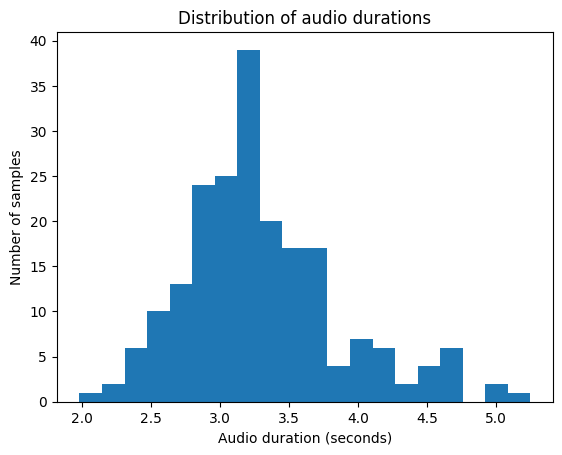

In [5]:
# Vaqt boyicha audiolarning massasini viuzllashtirish.

plt.hist(metadata["duration"], bins=20)
plt.xlabel("Audio duration (seconds)")
plt.ylabel("Number of samples")
plt.title("Distribution of audio durations")
plt.show()


### Audio davomiyligi statistikasi

* Ma'lumotlar to'plami 206 ta audio namunadan iborat bo'lib, ularning o'rtacha davomiyligi 3.3 soniyani tashkil etadi.
* Aksariyat namunalar 2–4 soniya oralig'iga to'g'ri keladi, bu esa STT tizimlari uchun juda mos keladi.
* Standart og'ishning pastligi segmentatsiyaning bir xilligini ko'rsatadi va keskin farq qiluvchi chetlanishlar kuzatilmadi.
* metadata.csv fileni o'zim yozib chiqqanim uchun undagi bo'sh qatorlar, kamchiliklarni tekshirmadim.

In [6]:
# Transcriptda ishlatilgan top 10 ta so'zni korish.

texts = metadata["transcript"].astype(str)

all_words = []
for sentence in texts:
    all_words.extend(sentence.split())

word_freq = Counter(all_words)

word_freq.most_common(10)


[('kerak', 27),
 ('qilish', 15),
 ('juda', 14),
 ('bilan', 14),
 ('uchun', 10),
 ('bugun', 9),
 ('muhim', 9),
 ('va', 9),
 ('zarur', 9),
 ('yaxshi', 8)]

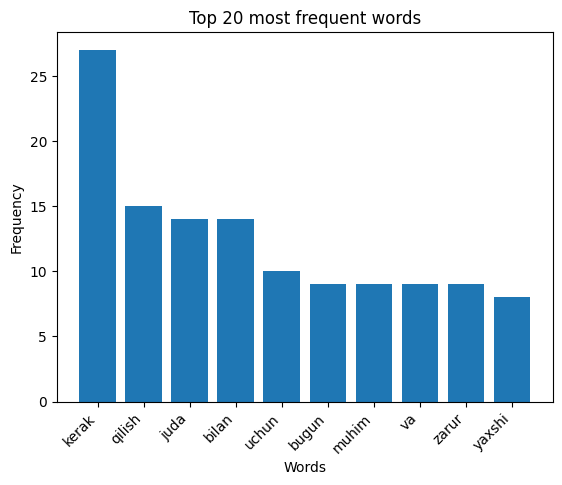

In [7]:
# top 10 ta so'zlarni vizuallashtirish.

common_words = word_freq.most_common(10)
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 most frequent words")
plt.show()


### So'zlar chastotasi tahlili

* Eng ko'p takrorlanadigan so'zlar qatoriga kundalik o'zbek nutqida keng qo'llaniladigan **"kerak"**, **"qilish"**, **"bilan"** va **"uchun"** kabi so'zlar kiradi.
* Bu ma'lumotlar to'plami sun'iy yoki oldindan yozib olingan ssenariylardan ko'ra ko'proq tabiiy so'zlashuv uslubini o'zida aks ettirganidan dalolat beradi.
*  metadata.csv fileni o'zim yozib chiqqanim uchun undagi bo'sh qatorlar, kamchiliklarni tekshirmadim.



In [8]:
# Har bir audio faylni o‘qib, undan MFCC xususiyatlarini hisoblaydi va barcha audio’lar uchun bir xil o‘lchamdagi MFCC matritsa hosil qiladi.
def extract_mfcc(
    file_path,
    sample_rate=16000,
    n_mfcc=13,
    n_fft=400,
    hop_length=160,
    max_len=300
):

    signal, sr = librosa.load(file_path, sr=sample_rate)


    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )


    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc


In [9]:

# barcha audiolar uchun MFCC qiymatlarini hisoblash.
X = []

for file in metadata["filename"]:
    path = os.path.join(audio_dir, file)
    mfcc = extract_mfcc(path)
    X.append(mfcc)

X = np.array(X)

X.shape


(206, 13, 300)

### MFCC belgilarini ajratib olish

* Har bir audio fayldan qat'iy belgilangan uzunlik (**fixed-length**) usuli yordamida **Mel-Frequency Cepstral Coefficients (MFCC)** belgilari ajratib olindi.
* Ma'lumotlar to'plami bo'ylab belgilar o'lchamining bir xilligini ta'minlash uchun to'ldirish (**padding**) va qisqartirish (**truncation**) usullari qo'llanildi.
* Bu jarayon natijasida ma'lumotlar **(206, 13, 300)** shakliga (tensor ko'rinishiga) keltirildi.


In [10]:
# olingan qiymatlarni train va test qiymatlarga ajratish.
X_train, X_temp = train_test_split(
    X,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)



Train shape: (144, 13, 300)
Validation shape: (31, 13, 300)
Test shape: (31, 13, 300)


### Ma'lumotlar to'plamini qismlarga ajratish

* Ma'lumotlar to'plami **70/15/15** nisbatda o'quv (**training**), tekshiruv (**validation**) va test (**test**) to'plamlariga ajratildi.
* Natijalarning takrorlanuvchanligini ta'minlash uchun ma'lumotlarni aralashtirish (**shuffling**) va qat'iy tasodifiy sonlar generatori (**fixed random seed**) qo'llanildi.


In [11]:
# Ajratilgan malumotlarni saqlash.
np.save("data/X_train.npy", X_train)
np.save("data/X_val.npy", X_val)
np.save("data/X_test.npy", X_test)


### Data Export

The processed feature sets were saved in NumPy format to enable
easy reuse for model training and evaluation.


In [12]:
# X_train dataning shapeni korish.
np.load("data/X_train.npy").shape


(144, 13, 300)

## Yakuniy xulosa

* Ushbu loyiha **Nutqni matnga aylantirish (STT)** tizimlari uchun nutq ma'lumotlar to'plamini tayyorlashning to'liq bosqichlarini (**pipeline**) qamrab oldi.
* Audio ma'lumotlar mustaqil ravishda to'plandi, tozalandi va ma'lumotlarni dastlabki o'rganish (**EDA**) usullari yordamida tahlil qilindi.
* **MFCC** belgilari qat'iy belgilangan uzunlik usuli asosida ajratib olindi hamda ma'lumotlar to'plami o'quv, tekshiruv va test qismlariga ajratildi.
* Tayyorlangan ma'lumotlar modelni o'qitishning keyingi bosqichlari uchun to'liq tayyor holatga keltirildi.